<a href="https://colab.research.google.com/github/Tr0lli/Progetto_Metodi_del_Calcolo_Scientifico/blob/master/Prova_Advanced_machine_learning_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

!pip install keras-tuner --quiet
import keras_tuner as kt
from tensorflow import keras
from time import time
from sklearn.metrics import classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
csv_file_path = os.path.join(path, "UCI_Credit_Card.csv")

original_df = pd.read_csv(csv_file_path)
original_df

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
# Elimino se presenti i valori nulli e la colonna relativa all'id (come id utilizzo quello del data-frame)
clean_df = original_df.dropna().reset_index(drop=True)
clean_df = clean_df.drop(columns=["ID"])
clean_df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


# Elenco e descrizione delle variabili rimanenti

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
* SEX: Gender (1=male, 2=female)
* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
* MARRIAGE: Marital status (1=married, 2=single, 3=others)
* AGE: Age in years
* PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
* PAY_2: Repayment status in August, 2005 (scale same as above)
* PAY_3: Repayment status in July, 2005 (scale same as above)
* PAY_4: Repayment status in June, 2005 (scale same as above)
* PAY_5: Repayment status in May, 2005 (scale same as above)
* PAY_6: Repayment status in April, 2005 (scale same as above)
* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
* BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
* BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar) default.payment.next.month: Default payment (1=yes, 0=no)
* default.payment.next.month: Default payment (1=yes, 0=no)

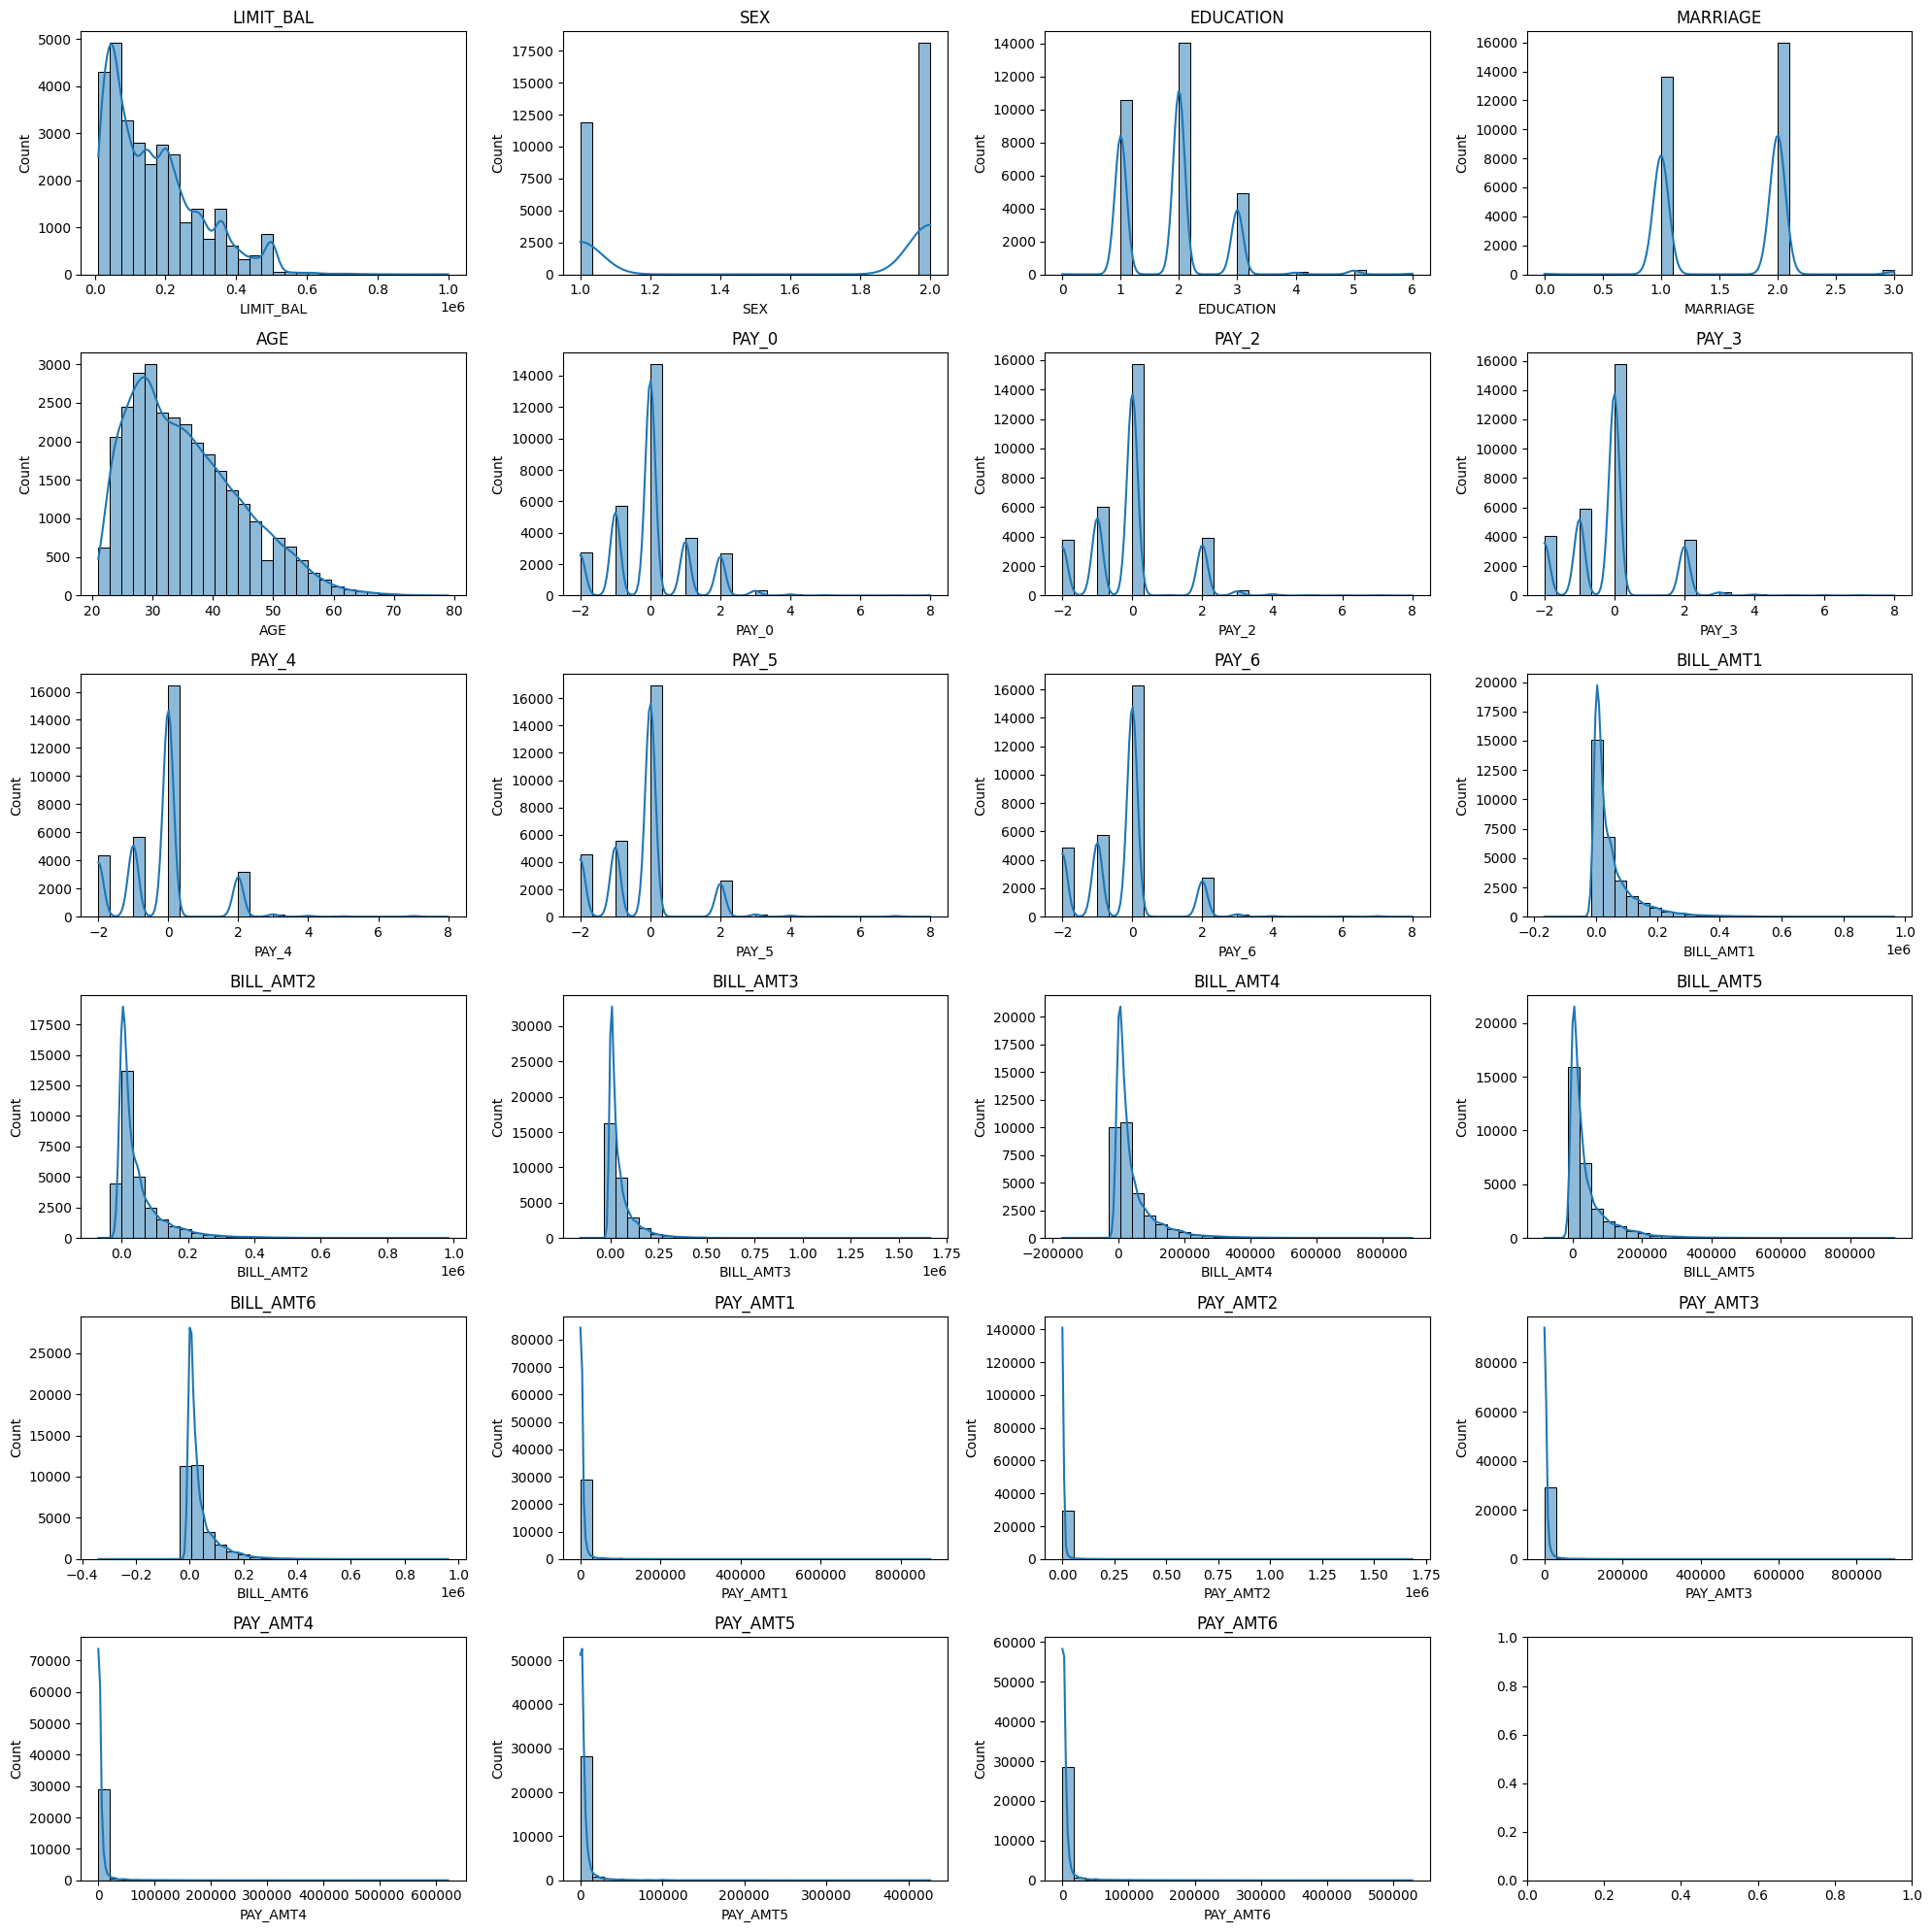

In [ ]:
# Separo le istanze dalla variabile target e visualizzo la loro distribuzione

target = clean_df["default.payment.next.month"]
instances = clean_df.drop(columns=["default.payment.next.month"])

num_cols = instances.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(instances[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Stampo a schermo le statistiche descrittive del data set
instances.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


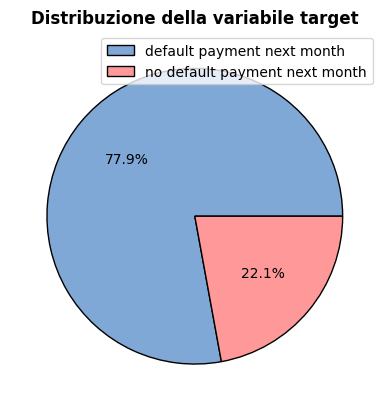

In [ ]:
colors = ["#7FA8D6", "#FF9999"]
wedges, _, _ = plt.pie(
    target.value_counts(),
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    autopct='%1.1f%%'
)
plt.legend(wedges, ["default payment next month", "no default payment next month"], loc="upper right")
plt.title("Distribuzione della variabile target", fontweight="bold")

plt.show()

In [ ]:
# Effettuo la standardizzazione dei dati per applicare la PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(instances)
scaled_data

array([[-1.13672015,  0.81016074,  0.18582826, ..., -0.30806256,
        -0.31413612, -0.29338206],
       [-0.3659805 ,  0.81016074,  0.18582826, ..., -0.24422965,
        -0.31413612, -0.18087821],
       [-0.59720239,  0.81016074,  0.18582826, ..., -0.24422965,
        -0.24868274, -0.01212243],
       ...,
       [-1.05964618, -1.23432296,  0.18582826, ..., -0.03996431,
        -0.18322937, -0.11900109],
       [-0.67427636, -1.23432296,  1.45111372, ..., -0.18512036,
         3.15253642, -0.19190359],
       [-0.90549825, -1.23432296,  0.18582826, ..., -0.24422965,
        -0.24868274, -0.23713013]])

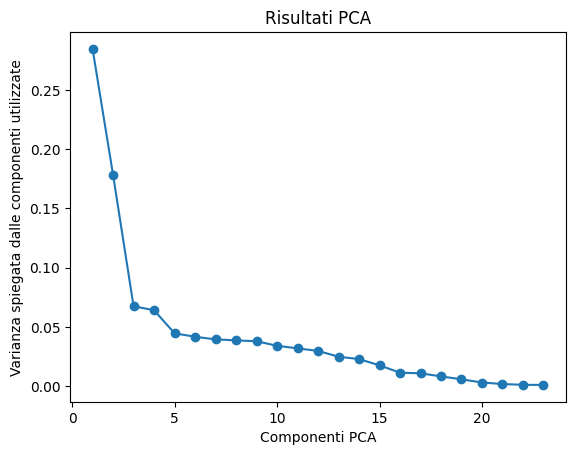

In [ ]:
# Applicazione della PCA
pca = PCA().fit(scaled_data)

# Grafico risultati della pca
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Componenti PCA')
plt.ylabel('Varianza spiegata dalle componenti utilizzate')
plt.title("Risultati PCA")
plt.show()

In [ ]:
# Selezionando 15 componenti si speiga il 95% della varianza complessiva dei dati

pca_components_number = 15
pca = PCA(pca_components_number).fit(scaled_data)
pca_data = pca.transform(scaled_data)
sum(pca.explained_variance_ratio_)

np.float64(0.957002282256061)

In [ ]:
# Creo un data frame con i componenti della PCA

pca_df = pd.DataFrame(pca_data, columns=[f"PC{i+1}" for i in range(pca_components_number)])
pca_df["default.payment.next.month"] = target
instances_pca = pca_df.drop('default.payment.next.month', axis=1)

# Suddivido i dati in training, validation e test (divisione 60-20-20)
X_train_validation, X_test, y_train_validation, y_test = train_test_split(instances_pca, target, test_size=0.2, random_state=42, stratify=target)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation, y_train_validation, test_size=0.25, random_state=42, stratify=y_train_validation
)

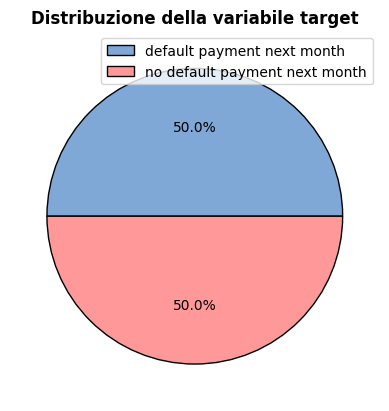

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

colors = ["#7FA8D6", "#FF9999"]
wedges, _, _ = plt.pie(
    y_train_res.value_counts(),
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    autopct='%1.1f%%'
)
plt.legend(wedges, ["default payment next month", "no default payment next month"], loc="upper right")
plt.title("Distribuzione della variabile target", fontweight="bold")

plt.show()

In [ ]:
def build_nn_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train_res.shape[1],)))

    # Hidden layers
    for i in range(hp.Int("num_layers", 1, 2)):
        model.add(keras.layers.Dense(
            units=hp.Int(f"units_{i}", 32, 128, step=32),
            activation='relu'
        ))
        model.add(keras.layers.Dropout(hp.Float(f"dropout_{i}", 0.1, 0.4, step=0.1)))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice("learning_rate", [1e-3, 1e-4])
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Usa solo una parte del dataset per tuning
X_tune, _, y_tune, _ = train_test_split(X_train_res, y_train_res, test_size=0.8, random_state=42, stratify=y_train_res)

# Tuner più leggero
nn_tuner = kt.RandomSearch(
    build_nn_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="nn_tuner_results",
    project_name="credit_nn_tuning"
)

# Ricerca
nn_tuner.search(
    X_tune, y_tune,
    validation_data=(X_validation, y_validation),
    epochs=10,
    batch_size=128,
    verbose=2
)

# Recupera i migliori iperparametri
nn_best_hps = nn_tuner.get_best_hyperparameters(num_trials=1)[0]

# Costruisci e addestra il modello finale
nn_best_model = build_nn_model(nn_best_hps)
history = nn_best_model.fit(
    X_train_res, y_train_res,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=128,
    verbose=1
)

# Valutazione
test_loss, test_acc = nn_best_model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predizioni
y_pred_nn = (nn_best_model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred_nn))

Trial 5 Complete [00h 00m 08s]
val_accuracy: 0.7114999890327454

Best val_accuracy So Far: 0.7910000085830688
Total elapsed time: 00h 00m 42s
Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5830 - loss: 0.6716 - val_accuracy: 0.7702 - val_loss: 0.5912
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6730 - loss: 0.6041 - val_accuracy: 0.7865 - val_loss: 0.5909
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6841 - loss: 0.5941 - val_accuracy: 0.7887 - val_loss: 0.5714
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6889 - loss: 0.5889 - val_accuracy: 0.7825 - val_loss: 0.5794
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6907 - loss: 0.5784 - val_accuracy: 0.7722 - val_loss: 0.5847
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6964 - loss: 0.5798 - val_accuracy: 0.7770 - val_loss: 0.5714
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6994 - loss: 0.5747 - v

In [ ]:
# Creiamo il tuner
nn_tuner = kt.BayesianOptimization(
    build_nn_model,
    objective="val_accuracy",  # Ottimizziamo la accuracy sul validation set
    max_trials=15,  # Numero massimo di combinazioni di iperparametri da testare
    executions_per_trial=3,  # Numero di volte che ogni modello viene eseguito (per ridurre variazioni casuali)
    directory="nn_tuner_results",  # Cartella in cui salvare i risultati
    project_name="lol_nn_model_tuning"  # Nome del progetto
)

nn_tuner.search(
    X_train_res, y_train_res,
    validation_data=(X_validation, y_validation),
    epochs=15,
    batch_size=64,
    verbose=2
)

Trial 15 Complete [00h 01m 13s]
val_accuracy: 0.782111128171285

Best val_accuracy So Far: 0.7841666539510092
Total elapsed time: 00h 17m 40s


In [ ]:
nn_best_hps = nn_tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\tMigliori iperparametri trovati\n")
print(f"Numero di layer nascosti: {nn_best_hps.get('num_layers')}\n")

for i in range(nn_best_hps.get("num_layers")):
  print(f"Informazioni relative al layer nascosto {i+1}:")
  print(f"- Numero di neuroni: {nn_best_hps.get(f'units_{i}')}")
  print(f"- Dropout: {nn_best_hps.get(f'dropout_{i}'):.1f}")
print(f"\nLearning rate: {nn_best_hps.get('learning_rate')}")

	Migliori iperparametri trovati

Numero di layer nascosti: 1

Informazioni relative al layer nascosto 1:
- Numero di neuroni: 32
- Dropout: 0.2

Learning rate: 0.001


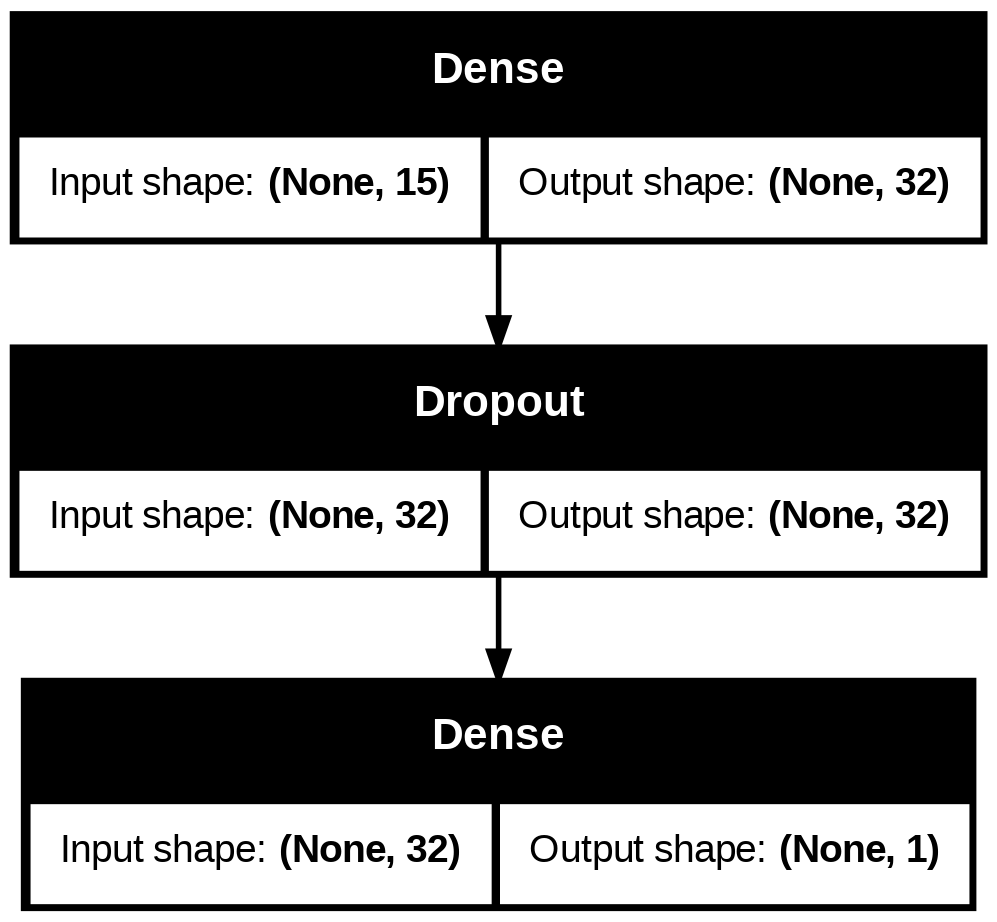

In [ ]:
nn_best_model = build_nn_model(nn_best_hps)
keras.utils.plot_model(nn_best_model, show_shapes=True)

In [ ]:
# Addestramento del modello
star_time_nn = time()
neural_network_history = nn_best_model.fit(
    X_train_res, y_train_res,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=128,
    verbose=1
)
# numero di epoche = numero di iterazioni
# batch_size = 32 significa che calcola il gradiente su 32 elementi del training set
end_time_nn = time()
training_time_nn = end_time_nn - star_time_nn
print(f"\nTempo di addestramento: {training_time_nn: .2f} secondi")

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5818 - loss: 0.6883 - val_accuracy: 0.7102 - val_loss: 0.6131
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6727 - loss: 0.6089 - val_accuracy: 0.7560 - val_loss: 0.6055
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6779 - loss: 0.5952 - val_accuracy: 0.7707 - val_loss: 0.5892
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6925 - loss: 0.5855 - val_accuracy: 0.7842 - val_loss: 0.5804
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6920 - loss: 0.5864 - val_accuracy: 0.7743 - val_loss: 0.5875
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6976 - loss: 0.5845 - val_accuracy: 0.7753 - val_loss: 0.5871
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6999 - loss: 0.5785 - val_accuracy: 0.7797 - val_loss: 0.5756
Epoch 8/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6986 - loss: 0.5788 - val_accuracy: 0.

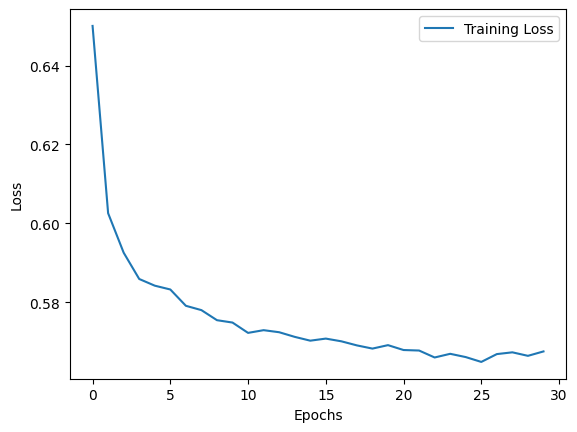

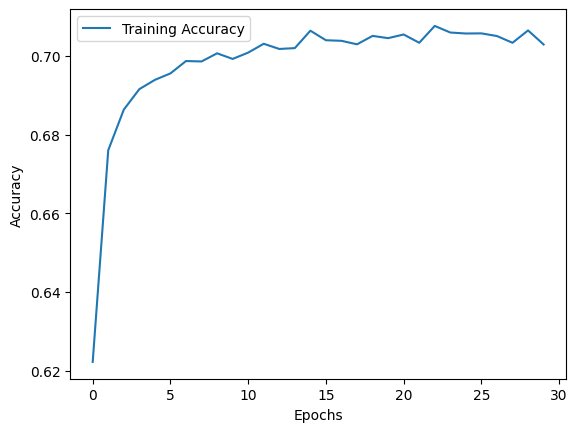

In [ ]:
history_dict = neural_network_history.history

# Plot della loss
plt.plot(history_dict['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot dell'accuracy
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = nn_best_model.evaluate(X_test, y_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7653 - loss: 0.5732


In [ ]:
y_pred_neural_network = nn_best_model.predict(X_test)
y_pred_classes_nn = (y_pred_neural_network > 0.5).astype(int)

classification_report_nn = classification_report(y_test, y_pred_classes_nn)
print(f"\nTest Accuracy: {test_acc:.10f}")
print("Classification report: \n", classification_report_nn)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Test Accuracy: 0.7626666427
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.59      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.79      0.76      0.77      6000

